## Ridge & Lasso Regression

- Regulation is a technique to reduce overfitting by penalizing large coefficients.
- instead of only minimizing error, we also control model complexity.
  - Loss = Error + Penalty
 
### Why Regulation is needed

- Too many features
- Polynomial regression
- Multicollinearity
- Noisy Data

### Types of Regulization
- L1 Regulization (Lasso Regression)
- L2 Regulization (Ridge Regression)
- Elastic Net (L1 +L2)

### Ridge Regression - (L2 Regulization)
- Ridge Regression is a regularization technique used to reduce overfitting by adding a penalty term based on the square of coefficients to the loss function.
- Loss = MSE+λ∑W²

### Why Ridge Regression is Needed
- Linear and Polynomial model tend to overfit.
- Large coefficients make the model unstable.
- Multicollinearity causes coefficient fluctuation.

#### Note:
- Ridge controls model complexity.

### lasso  Regression (L1 Regulization)
- Lasso Regression is a regulization technique used to reduce overfitting by adding penality based on the absolute value of coefficients, which can force some coefficients to become exactly zero.
- LASSO: Least Absolute Shrinkage and selection Operator.
- Loss = MSE+λ∑|W|

### Why Lasso Regresssion is needed
- Some datasets contains irrelevent or noisy features.
- Too many features increase model complexity.
- Difficult to interpret models with many coefficients.
#### Nots:
- Lasso simplifies the model by removing unnecessary features

### Use Ridge when:
- Many correlated features
- All variables are important

### Use Lasso when:
- Too Many Features
- Need feature selection


# Coding

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge,LinearRegression,Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [8]:
data= {
    "Area": [800,900,1000,1100,1200,1300,1400,1500,1600,1700],
    "Bedrooms":[1,2,2,2,3,3,3,4,4,4],
    "Bathrooms":[1,1,2,2,2,2,3,3,3,3],
    "Age":[15,12,10,8,6,5,4,3,2,1],
    "Distance_City":[15,14,13,12,10,9,8,7,6,5],
    "Price":[40,50,55,60,70,75,80,90,95,100]
}
df=pd.DataFrame(data)
df

,Area,Bedrooms,Bathrooms,Age,Distance_City,Price
0,800,1,1,15,15,40
1,900,2,1,12,14,50
2,1000,2,2,10,13,55
3,1100,2,2,8,12,60
4,1200,3,2,6,10,70
5,1300,3,2,5,9,75
6,1400,3,3,4,8,80
7,1500,4,3,3,7,90
8,1600,4,3,2,6,95
9,1700,4,3,1,5,100


In [9]:
X= df.drop("Price",axis=1) # Multiple columns
y= df["Price"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
scaler = StandardScaler()
X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)

LinearRegression()

In [19]:
ridge = Ridge(alpha=2.0)
ridge.fit(X_train_scaled, y_train)

Ridge(alpha=2.0)

In [20]:
y_train_pred_lin = linear.predict(X_train_scaled)
y_test_pred_lin = linear.predict(X_test_scaled)

In [22]:
train_mse_lin = mean_squared_error(y_train, y_train_pred_lin)
test_mse_lin = mean_squared_error(y_test, y_test_pred_lin)

In [23]:
print("Train MSE:",train_mse_lin)
print("Test MSe:",test_mse_lin)

Train MSE: 5.679798517591285e-29
Test MSe: 2.0194839173657902e-28


In [27]:
y_train_pred_rid = ridge.predict(X_train_scaled)
y_test_pred_rid = ridge.predict(X_test_scaled)

In [28]:
train_mse_rid = mean_squared_error(y_train, y_train_pred_rid)
test_mse_rid = mean_squared_error(y_test, y_test_pred_rid)
print("Train MSE:",train_mse_rid)
print("Test MSe:",test_mse_rid)

Train MSE: 2.72580460390538
Test MSe: 3.19803774145094


<function matplotlib.pyplot.show(close=None, block=None)>

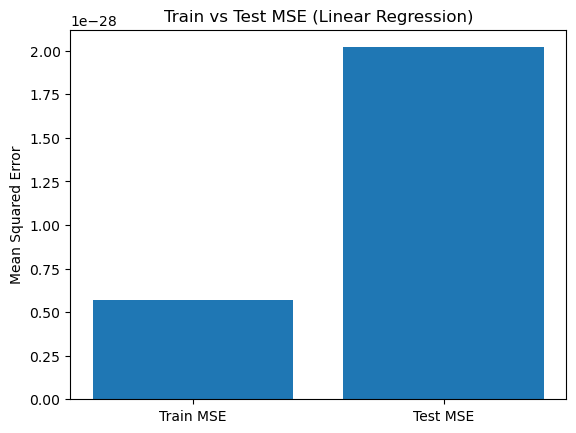

In [30]:
plt.bar(["Train MSE", "Test MSE"], [train_mse_lin, test_mse_lin])
plt.ylabel("Mean Squared Error")
plt.title("Train vs Test MSE (Linear Regression)")
plt.show

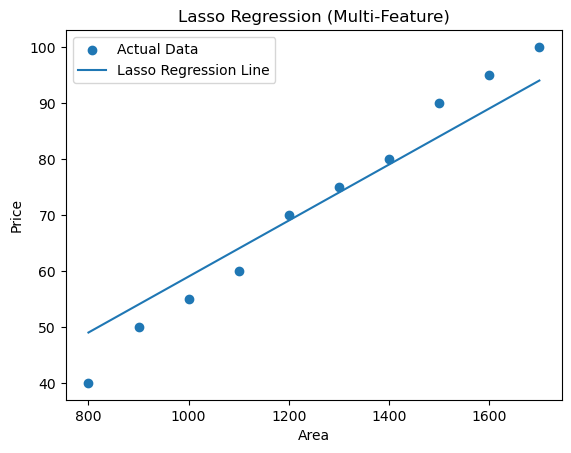

In [59]:
X_plot_scaled = scaler.transform(X_plot)
y_line = linear.predict(X_plot_scaled)
plt.scatter(df["Area"], df["Price"], label="Actual Data")
plt.plot(X_plot["Area"], y_line, label="Lasso Regression Line")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Lasso Regression (Multi-Feature)")
plt.legend()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

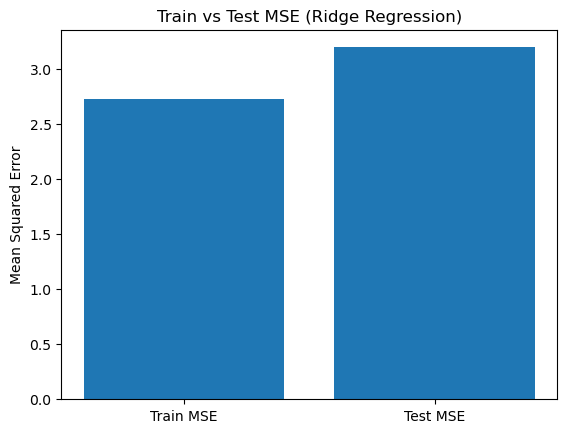

In [31]:
plt.bar(["Train MSE", "Test MSE"], [train_mse_rid, test_mse_rid])
plt.ylabel("Mean Squared Error")
plt.title("Train vs Test MSE (Ridge Regression)")
plt.show

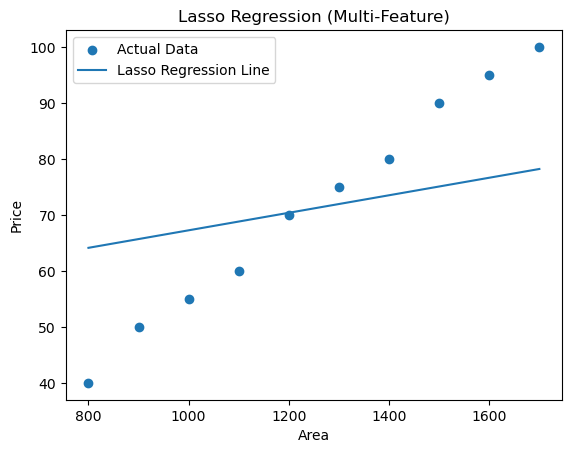

In [60]:
X_plot_scaled = scaler.transform(X_plot)
y_line = ridge.predict(X_plot_scaled)
plt.scatter(df["Area"], df["Price"], label="Actual Data")
plt.plot(X_plot["Area"], y_line, label="Lasso Regression Line")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Lasso Regression (Multi-Feature)")
plt.legend()
plt.show()

## Lasso Regression

In [52]:
lasso = Lasso(alpha=0.5)  # alpha = regulization strength
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.5)

In [53]:
y_train_pred = lasso.predict(X_train_scaled)
y_test_pred = lasso.predict(X_test_scaled)

In [54]:
train_mse_lasso = mean_squared_error(y_train, y_train_pred)
test_mse_lasso = mean_squared_error(y_test, y_test_pred)

In [55]:
print("Train MSE:",train_mse_lasso)
print("Test MSe:",test_mse_lasso)

Train MSE: 0.2540521315349213
Test MSe: 0.35590211738900734


<function matplotlib.pyplot.show(close=None, block=None)>

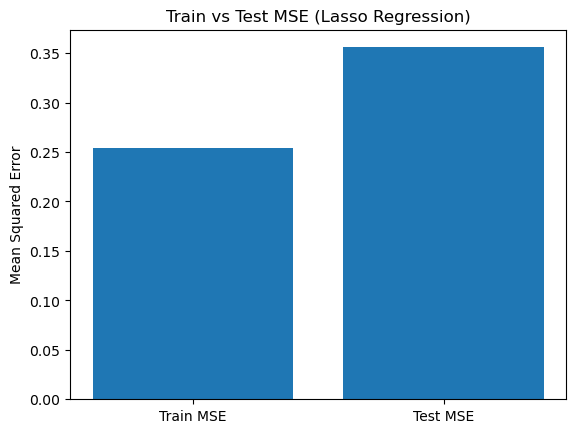

In [56]:
plt.bar(["Train MSE", "Test MSE"], [train_mse_lasso, test_mse_lasso])
plt.ylabel("Mean Squared Error")
plt.title("Train vs Test MSE (Lasso Regression)")
plt.show

In [57]:
X_plot = pd.DataFrame({
"Area": np.linspace(df["Area"].min(), df["Area"].max(), 100),
"Bedrooms": df[ "Bedrooms"].mean(),
"Bathrooms": df["Bathrooms"].mean(),
"Age": df["Age"].mean(),
"Distance_City": df ["Distance_City"].mean()
})

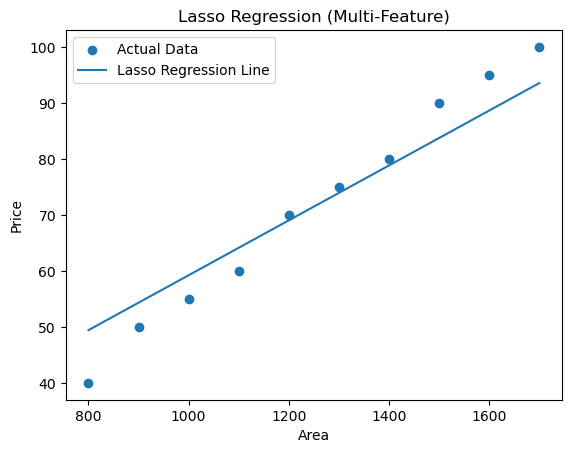

In [58]:
X_plot_scaled = scaler.transform(X_plot)
y_line = lasso.predict(X_plot_scaled)
plt.scatter(df["Area"], df["Price"], label="Actual Data")
plt.plot(X_plot["Area"], y_line, label="Lasso Regression Line")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Lasso Regression (Multi-Feature)")
plt.legend()
plt.show()